# Figure 5 Supplement 1: Phase-dependent effects on dendritic spikes of beta and gamma rhythmic inhibition delivered to opposite areas of the neuron

**Paper:** Headley DB, Latimer B, Aberbach A, Nair SS (2026). Spatially targeted inhibitory rhythms differentially affect neuronal integration. *eLife*. https://doi.org/10.7554/eLife.95562

## Overview

This notebook analyzes a critical control experiment testing the location-specificity of beta and gamma rhythmic inhibition effects. In Figure 5, beta rhythmic inhibition was delivered to distal dendrites and gamma to the perisomatic region. Here, we test the opposite configuration by swapping the locations of beta and gamma synapses to disassociate the frequency of inhibition from its location:

- **Beta (16 Hz) rhythmic inhibition** delivered **perisomatically** (instead of distal dendrites)
- **Gamma (64 Hz) rhythmic inhibition** delivered to **distal dendrites** (instead of perisomatic)

## Key Findings from the Paper

As described in the paper, swapping the location of beta and gamma synapses altered their effects on somatic excitability. While phase modulation of firing rate was maintained with both rhythms, the overall level of spiking was dramatically reduced. Neither rhythm modulated Ca²⁺ or NMDA spikes in this reversed configuration.

It is likely that the slow time scale of Ca²⁺ and NMDA spikes, ~50 ms, is not optimal for the fast periodicity of the gamma rhythm, which cycles every ~15 ms. In agreement with this, Na⁺ spikes, which last less than 1 ms, did show modulation by gamma rhythms delivered to the distal dendrites.

Gamma rhythmic inhibition on the dendrites had minimal or no impact on action potential threshold, but did shift the somatic membrane potential more negative. This hyperpolarization was not dependent on gamma phase, and likely reflected an overall decrease in the rate of dendritic spikes that could supply excitatory drive to the soma (NMDA: -26.1%, Na⁺: -12.2%, and Ca²⁺: -39.9% compared with the Poisson inhibition case). By contrast, delivering beta rhythmic inhibition to the soma raised the action potential threshold and hyperpolarized the membrane potential during the peak phase. It also reduced the incidence of dendritic spikes (NMDA: -17.1%, Na⁺: -11.5%, and Ca²⁺: -7.6%).

Putting all this together, the effectiveness of rhythmic inhibition depends on where it impinges upon the neuron. Beta rhythms targeting the distal dendrites modulate the incidence of dendritic spikes in a phase-dependent manner, while gamma rhythms delivered perisomatically phase modulate somatic excitability. Swapping the locations of these rhythms diminishes these effects and lowers overall excitability.

In [28]:
import sys
sys.path.append('..') # have to do this for relative imports in jupyter
import numpy as np
import pandas as pd
import h5py
from scipy.signal import hilbert
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from src.bin_rhythmic_files import bin_rhythmic_files
from src.load_spike_h5 import load_spike_h5
from src.ser_pt import ser_pt
from src.bin_serser import bin_serser
from src.cc_phdep_files import cc_phdep_files

from src.load_dendevt_csv import load_dendevt_csv
from src.seg_dendevt import seg_dendevt
from src.ser_seg_dendevt import ser_seg_dendevt
from src.mean_dendevt import mean_dendevt

## 1.0 Analysis Parameters

Define parameters for phase-binned analysis. Events are binned into 8 phase bins from -π to π radians based on the sinusoidal modulation of inhibitory drive, where -π represents the trough (minimum inhibition) and 0 represents the peak (maximum inhibition).

### 1.1 Simulation Constants and Analysis Windows

Set sampling rate (10 samples/ms), simulation window (200 seconds), and phase binning parameters (8 bins spanning -π to π radians).

In [29]:
samps_per_ms = 10 
sim_win = [0, 2000000] # beginning and start points of simulation in samples
sta_win = [-100, 100] # multiply by step to get window in milliseconds
sta_step = 1 # binning step for each point in the STA
step = 2 * samps_per_ms # number of simulation steps for creating the dendritic 
                        # event occurrence series
ph_bin_num = 8
edges = np.linspace(-np.pi, np.pi, ph_bin_num)

### 1.2 Simulation Files (Reversed Rhythm Locations)

Define paths to simulation output files for the reversed rhythm configuration:

1. **16 Hz beta rhythmic inhibition** delivered **perisomatically** (soma and dendrites <100 µm)
2. **64 Hz gamma rhythmic inhibition** delivered to **distal dendrites** (>100 µm from soma)

This is the opposite of the standard configuration in Figure 5, allowing us to test whether the effectiveness of rhythmic inhibition depends on where it impinges upon the neuron.

In [30]:
# locate simulation files
root_16_dir = 'D:\\DendCompOscPublic\\output_16Hz_on_soma_dom_20p\\'
sim_16_dict = {'SimName': 'output_16Hz_on_soma_dom',
               'RootDir': root_16_dir,
               'CaFile': root_16_dir + 'output_16Hz_on_soma_dom_20p_ca.csv',
               'NaFile': root_16_dir + 'output_16Hz_on_soma_dom_20p_na.csv',
               'NMDAFile': root_16_dir + 'output_16Hz_on_soma_dom_20p_nmda.csv',
               'APFile': root_16_dir + 'spikes.h5',
               'InhProxFile': root_16_dir + 'prox_inh_stim_spikes.h5',
               'InhDistFile': root_16_dir + 'dist_inh_stim_spikes.h5', 
               'VmFile': root_16_dir + 'v_report.h5'}

root_64_dir = 'D:\\DendCompOscPublic\\output_64Hz_on_dends_dom_40p\\'
sim_64_dict = {'SimName': 'output_64Hz_on_dends',
               'RootDir': root_64_dir,
               'CaFile': root_64_dir + 'output_64Hz_on_dends_dom_40p_ca.csv',
               'NaFile': root_64_dir + 'output_64Hz_on_dends_dom_40p_na.csv',
               'NMDAFile': root_64_dir + 'output_64Hz_on_dends_dom_40p_nmda.csv',
               'APFile': root_64_dir + 'spikes.h5',
               'InhProxFile': root_64_dir + 'prox_inh_stim_spikes.h5',
               'InhDistFile': root_64_dir + 'dist_inh_stim_spikes.h5', 
               'VmFile': root_64_dir + 'v_report.h5'}


## 2.0 Phase-Binned Histograms for Dendritic and Somatic Spikes

Compute entrainment of dendritic spikes and action potentials to the reversed rhythm configuration. As described in the paper, swapping rhythm locations impairs their effectiveness: neither rhythm modulates Ca²⁺ or NMDA spikes when delivered to the wrong location. The slow time scale of Ca²⁺ and NMDA spikes (~50 ms) is not optimal for the fast gamma periodicity (~15 ms cycle). Na⁺ spikes, which last less than 1 ms, did show modulation by gamma rhythms delivered to distal dendrites.

### 2.1 Generate Phase Series for Each Experiment

Generate sinusoidal time series at 16 Hz (beta) and 64 Hz (gamma) frequencies representing rhythmic modulation of inhibitory drive. Phase is extracted using the Hilbert transform to allow assignment of each event to a phase bin.

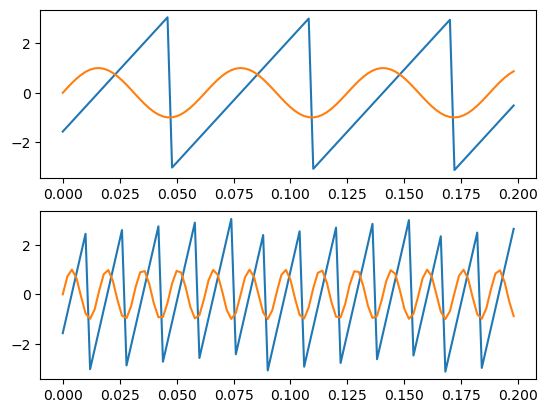

In [31]:
# generate phase time series for inhibitory afferents
t_ser = np.arange(sim_win[0], sim_win[1], step) / (10000) # seconds
sin_16_ser = np.sin(t_ser*16*2*np.pi)
sin_64_ser = np.sin(t_ser*64*2*np.pi)
ph_16_ser = np.angle(hilbert(sin_16_ser))
ph_64_ser = np.angle(hilbert(sin_64_ser))

fig, ax = plt.subplots(2,1)
ax[0].plot(t_ser[0:100],ph_16_ser[0:100])
ax[0].plot(t_ser[0:100],sin_16_ser[0:100])
ax[1].plot(t_ser[0:100],ph_64_ser[0:100])
ax[1].plot(t_ser[0:100],sin_64_ser[0:100])
#ax.plot(t_ser[0:100],ph_64_ser[0:100])
plt.show()

### 2.1.1 Parameters for Plotting Inhibitory Afferent Timing

Define parameters for visualizing the relationship between inhibitory spike timing and membrane potential to verify that rhythmic modulation occurs as expected.

In [32]:
# parmameters for plotting inhibitory afferent phase time series
inh_window = np.array([0, 0.5]) # seconds
bin_len = 0.004 # seconds

inh_16_offset = 97.0 # seconds 9
inh_64_offset = 0.93 # seconds

inh_16_edges = inh_16_offset + inh_window
inh_64_edges = inh_64_offset + inh_window
bin_num = int((inh_window[1] - inh_window[0]) / bin_len)

# compartments to plot
soma_ind = 2
basal_ind = 32
apic_ind = 1530

### 2.2 Calculate Phase-Binned Histograms

Process each simulation to compute phase-dependent modulation of dendritic spikes (Ca²⁺, NMDA, Na⁺) and action potentials. Events are converted to binary time series, binned by inhibitory rhythm phase, stratified by electrotonic distance, and expressed as percent change from mean incidence.

In [33]:
# phase bin dendritic and action potential files function
def bin_files_func(sim_dict, ph_ser, sin_ser):
    ph_bin = {}

    # process dendritic events
    ph_bin['ca_bin'] = bin_rhythmic_files(sim_dict['CaFile'], ph_ser, step, sim_win,ph_bin_num)
    ph_bin['nmda_bin'] = bin_rhythmic_files(sim_dict['NMDAFile'], ph_ser, step, sim_win,ph_bin_num)
    ph_bin['na_bin'] = bin_rhythmic_files(sim_dict['NaFile'], ph_ser, step, sim_win,ph_bin_num)

    ph_bin['ca_a'] = ph_bin['ca_bin'].loc['apic','ph_bin']
    ph_bin['nmda_a'] = ph_bin['nmda_bin'].loc['apic','ph_bin']
    ph_bin['nmda_b'] = ph_bin['nmda_bin'].loc['dend','ph_bin']
    ph_bin['na_a'] = ph_bin['na_bin'].loc['apic','ph_bin']
    ph_bin['na_b'] = ph_bin['na_bin'].loc['dend','ph_bin']
    

    # process action potential events
    spk_t = load_spike_h5(sim_dict['APFile'])
    spk_ser = ser_pt(spk_t, step, sim_win)
    spk_ser = np.array(spk_ser)*500
    # multiplying by 500 converts to firing rates, 2ms bin means 1 spike per bin
    # is a firing rate of 500 Hz.
    ph_bin['ap'] = bin_serser(spk_ser.astype(float), ph_ser, edges, func=np.nanmean)["values"]
    ph_bin['sin'] = bin_serser(sin_ser, ph_ser, edges, func=np.nanmean)["values"]
    return ph_bin



In [34]:
# process the 16 Hz distal dendritic inhibition simulation
ph_16_bin = bin_files_func(sim_16_dict, ph_16_ser, sin_16_ser)

# process the 64 Hz proximal dendritic/somatic inhibition simulation
ph_64_bin = bin_files_func(sim_64_dict, ph_64_ser, sin_64_ser)

c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\bin_serser.py:60: RuntimeWarning: Mean of empty slice
  bin_temp.append(func(val_ser[bin_inds == curr_ind]))
c:\Users\dbh60\.conda\envs\dend_comp\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\bin_serser.py:60: RuntimeWarning: Mean of empty slice
  bin_temp.append(func(val_ser[bin_inds == curr_ind]))
c:\Users\d

### 2.3 Visualization

Plot phase histograms showing event incidence as a function of rhythm phase, spanning 2 full cycles (-π to 3π) for clarity. These visualizations correspond to Figure 5 Supplement 1 panels from the paper: action potential rate (A, E), Ca²⁺ spike percent change (B, F), NMDA spike percent change (C, G), and Na⁺ spike percent change (D, H). In the reversed configuration, neither rhythm effectively modulates Ca²⁺ or NMDA spikes, demonstrating that rhythm effectiveness depends on spatial targeting.

In [35]:
# plotting functions
def stairs_plot(sig_ser, sin_ser, ax):
        sc_func = lambda x: ((x+1)/2)*np.max(sig_ser[1:])

        ax.stairs(np.hstack((sig_ser[1:],sig_ser[1:])),
                        np.hstack((edges[:-1], edges+2*np.pi)), 
                        baseline=0, fill=True)
        ax.plot(np.hstack((edges, edges+2*np.pi)), 
                np.hstack((sc_func(sin_ser), sc_func(sin_ser))),color='k')
        ax.plot(np.linspace(-np.pi,3*np.pi,100),
                sc_func(np.sin(np.linspace(-np.pi,3*np.pi,100)+(np.pi/2))), 
                color='r', linestyle=':')
        ax.set_xticks(np.pi/2*np.arange(-2,7))
        ax.tick_params(axis='x', rotation=90)

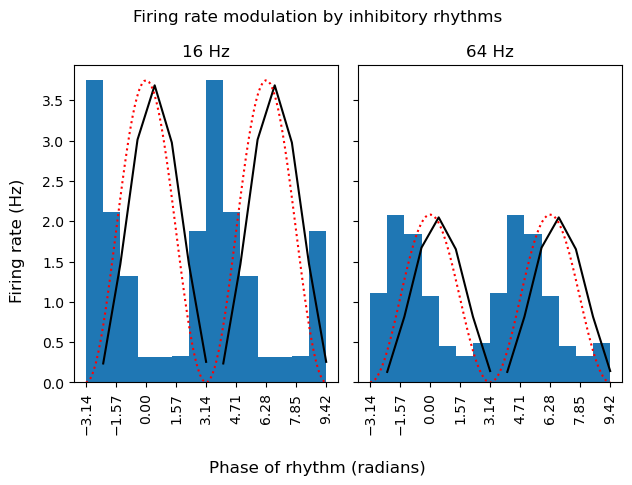

In [36]:
# Action potentials
fig, ax = plt.subplots(1,2,sharey=True)
stairs_plot(ph_16_bin['ap'], ph_16_bin['sin'], ax[0])
stairs_plot(ph_64_bin['ap'], ph_64_bin['sin'], ax[1])
ax[0].set_title('16 Hz')
ax[1].set_title('64 Hz')
fig.suptitle('Firing rate modulation by inhibitory rhythms')
fig.supxlabel('Phase of rhythm (radians)')
fig.supylabel('Firing rate (Hz)')
plt.tight_layout()



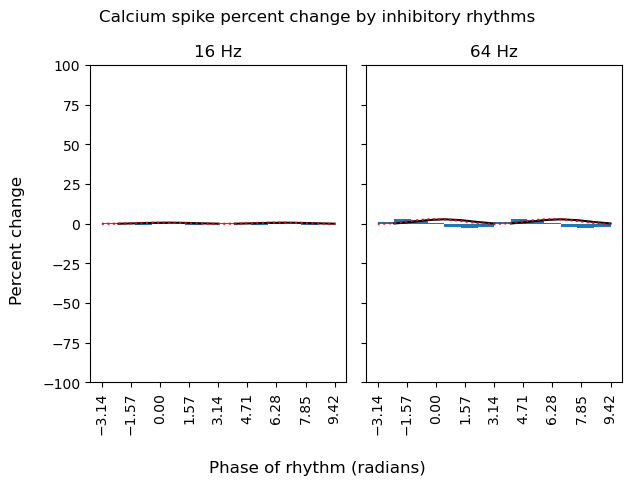

In [37]:
# calcium spikes
fig, ax = plt.subplots(1,2,sharey=True)
stairs_plot(ph_16_bin['ca_a'][0], ph_16_bin['sin'], ax[0])
stairs_plot(ph_64_bin['ca_a'][0], ph_64_bin['sin'], ax[1])
ax[0].set_ylim([-100,100])
ax[0].set_title('16 Hz')
ax[1].set_title('64 Hz')
fig.suptitle('Calcium spike percent change by inhibitory rhythms')
fig.supxlabel('Phase of rhythm (radians)')
fig.supylabel('Percent change')
plt.tight_layout()


### 2.4 Dendritic Event Modulation Heatmaps by Electrotonic Distance

Visualize dendritic spike modulation as heatmaps stratified by electrotonic distance (y-axis) and rhythm phase (x-axis). In the reversed configuration, gamma rhythmic inhibition on distal dendrites has minimal effect on Ca²⁺ and NMDA spikes because the slow time scale of these events (~50 ms) is not optimal for the fast gamma periodicity (~15 ms cycle). Similarly, beta on perisomatic regions does not effectively entrain dendritic spikes as it does when delivered to distal dendrites. This demonstrates that the effectiveness of rhythmic inhibition depends on where it impinges upon the neuron, and swapping the locations of these rhythms diminishes these effects and lowers overall excitability.

In [38]:
# plot phase-dependent modulation of dendritic events stratified by electrotonic distance
eqt_list = np.arange(9,0,-1)
eqt_inds = np.where(eqt_list>0)[0]
def plot_sta_im(data_arr,vlim, ax):
    ax_im = ax.imshow(np.hstack((data_arr[eqt_inds[0]:eqt_inds[-1],1:], 
                                 data_arr[eqt_inds[0]:eqt_inds[-1],1:])),
                      extent=[-np.pi, 3*np.pi, eqt_list[eqt_inds[0]], eqt_list[eqt_inds[-1]]],
                      vmin=vlim[0], vmax=vlim[1],
                      interpolation='none',
                      cmap='coolwarm')
    
    plt.colorbar(ax_im,ax=ax)
    ax.set_aspect('auto')

# array plots
def plot_dend_set(ph_bin_data, vlim, fig, ax):
    plot_sta_im(ph_bin_data['nmda_a'], vlim, ax[0,0])
    ax[0,0].set_title('NMDA Apical')
    ax[0,0].set_xticks(np.pi/2*np.arange(-2,7))
    ax[0,0].tick_params(axis='x', rotation=90)
    plot_sta_im(ph_bin_data['nmda_b'], vlim, ax[1,0])
    ax[1,0].set_title('NMDA Basal')
    ax[1,0].set_xticks(np.pi/2*np.arange(-2,7))
    ax[1,0].tick_params(axis='x', rotation=90)
    plot_sta_im(ph_bin_data['na_a'], vlim, ax[0,1])
    ax[0,1].set_title('Na Apical')
    ax[0,1].set_xticks(np.pi/2*np.arange(-2,7))
    ax[0,1].tick_params(axis='x', rotation=90)
    plot_sta_im(ph_bin_data['na_b'], vlim, ax[1,1])
    ax[1,1].set_title('Na Basal')
    ax[1,1].set_xticks(np.pi/2*np.arange(-2,7))
    ax[1,1].tick_params(axis='x', rotation=90)
    fig.supxlabel('Phase of rhythm (radians)')
    fig.supylabel('Electrotonic quantile 90->0')
    

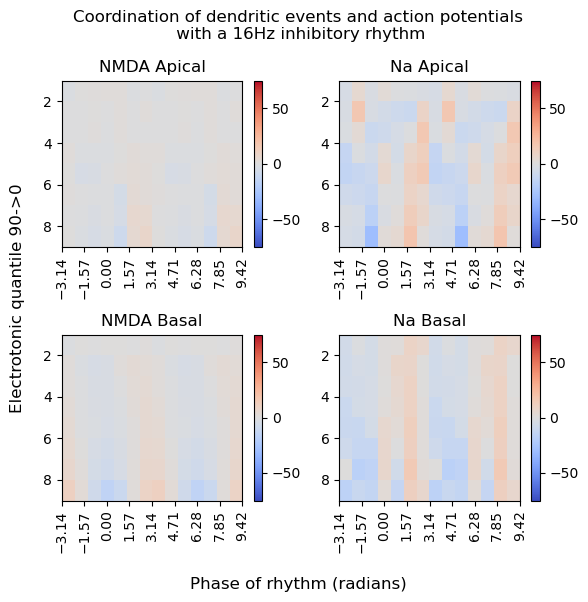

In [39]:
# plot of NMDA and Na spikes for 16 hz dend inhib
fig,ax = plt.subplots(2,2)
plot_dend_set(ph_16_bin, [-75, 75], fig, ax)
fig.suptitle('Coordination of dendritic events and action potentials\n'
             + ' with a 16Hz inhibitory rhythm')
fig.set_size_inches(6,6)
fig.tight_layout()



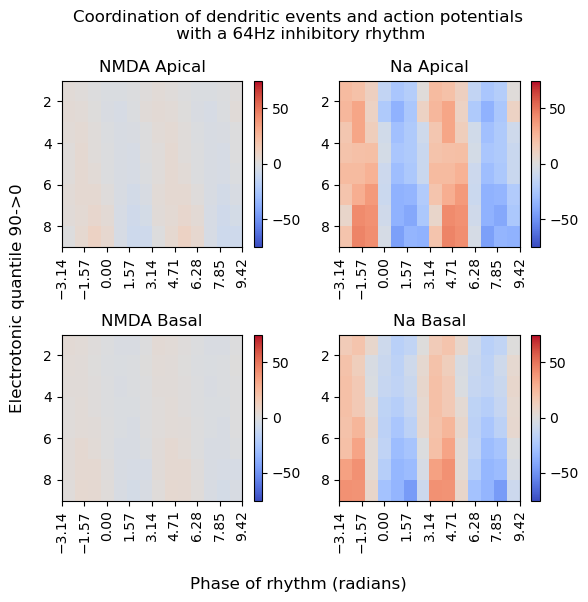

In [40]:
# plot of NMDA and Na spikes for 64 hz somatic inhib
fig,ax = plt.subplots(2,2)
plot_dend_set(ph_64_bin, [-75, 75], fig, ax)
fig.suptitle('Coordination of dendritic events and action potentials\n'
             + ' with a 64Hz inhibitory rhythm')
fig.set_size_inches(6,6)
fig.tight_layout()
